# Tutorial 14: Human-in-the-Loop with LangGraph

In this tutorial we explore one of the most powerful features of LangGraph: pausing graph execution to wait for human input, then resuming exactly where it left off — without blocking any threads.

## 1. Why Human-in-the-Loop?

Fully autonomous agents are powerful but risky. Human-in-the-Loop (HITL) lets you:
- **Approve actions** before an agent executes a tool
- **Correct mistakes** mid-execution without restarting
- **Review generated content** before it is sent to an end user

LangGraph makes this possible by checkpointing state after every node and suspending execution until the human responds. The wait can last seconds or days — the graph state is persisted safely.

## 2. Core Primitives

| Primitive | Purpose |
|---|---|
| `interrupt(value)` | Pause inside a node and surface `value` to the caller |
| `Command(resume=data)` | Resume execution, passing `data` back into the interrupted node |
| `MemorySaver` | Checkpointer that persists state between `.invoke()` calls |

## 3. Setup

In [1]:
import os
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage

llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0.1,
)

print("Setup complete.")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Setup complete.


## 4. Building an Approval Workflow

We will build a workflow where an agent drafts an email and then **waits for human approval** before sending it. If the human rejects the draft, the agent revises and asks again.

In [2]:
class EmailState(TypedDict):
    topic: str
    draft: str
    feedback: str
    approved: bool


def draft_email(state: EmailState) -> EmailState:
    """Agent drafts an email based on the topic."""
    feedback_context = ""
    if state.get("feedback"):
        feedback_context = f"\n\nPrevious feedback to incorporate: {state['feedback']}"

    prompt = f"Write a short professional email about: {state['topic']}{feedback_context}"
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"draft": response.content}


def human_review(state: EmailState) -> Command:
    """Pause and ask the human to approve or reject the draft."""
    print("\n--- EMAIL DRAFT ---")
    print(state["draft"])
    print("-------------------")

    # interrupt() pauses execution and surfaces the draft to the caller
    human_input = interrupt({
        "question": "Do you approve this draft? (yes / provide feedback)",
        "draft": state["draft"]
    })

    if human_input.lower() == "yes":
        return Command(update={"approved": True}, goto="send_email")
    else:
        return Command(update={"feedback": human_input, "approved": False}, goto="draft_email")


def send_email(state: EmailState) -> EmailState:
    """Simulate sending the approved email."""
    print(f"\n✓ Email sent successfully about: {state['topic']}")
    return state


# Build the graph
workflow = StateGraph(EmailState)
workflow.add_node("draft_email", draft_email)
workflow.add_node("human_review", human_review)
workflow.add_node("send_email", send_email)

workflow.set_entry_point("draft_email")
workflow.add_edge("draft_email", "human_review")
workflow.add_edge("send_email", END)

# MemorySaver is required for interrupt() to work
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

print("Graph compiled.")

Graph compiled.


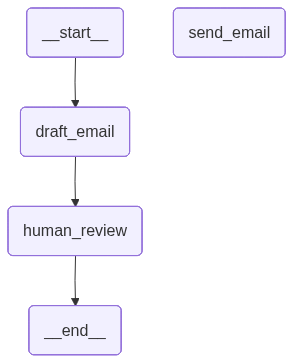

In [3]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## 5. Running the Workflow

Every run must use a `thread_id`. The graph pauses at `interrupt()` and raises a `GraphInterrupt` exception — we catch it to see what the agent is asking.

In [4]:
config = {"configurable": {"thread_id": "email-thread-1"}}

initial_input = {
    "topic": "announcing a team meeting next Monday at 10am",
    "draft": "",
    "feedback": "",
    "approved": False
}

# First invocation: runs until interrupt()
result = app.invoke(initial_input, config)
print("Graph paused — waiting for human input.")
print("Current state:", app.get_state(config).values.get("draft", "")[:100], "...")


--- EMAIL DRAFT ---
Subject: Upcoming Team Meeting - Next Monday at 10am

Dear Team,

I am writing to inform you that we will be holding a team meeting next Monday at 10am. This meeting will provide an opportunity for us to discuss ongoing projects, address any questions or concerns, and align on our priorities for the upcoming week.

Date: Next Monday
Time: 10am
Location: [Insert location or virtual meeting details]

I encourage all team members to attend and participate in the discussion. If you have any specific topics you would like to add to the agenda, please let me know by replying to this email.

Thank you for your cooperation and I look forward to seeing you all next Monday.

Best regards,
[Your Name]
-------------------
Graph paused — waiting for human input.
Current state: Subject: Upcoming Team Meeting - Next Monday at 10am

Dear Team,

I am writing to inform you that we ...


In [5]:
# Simulate human rejecting with feedback
feedback = "Please make the tone more casual and add the Zoom link placeholder."

# Resume by passing Command(resume=feedback)
result = app.invoke(Command(resume=feedback), config)
print("Graph paused again with revised draft.")


--- EMAIL DRAFT ---
Subject: Upcoming Team Meeting - Next Monday at 10am

Dear Team,

I am writing to inform you that we will be holding a team meeting next Monday at 10am. This meeting will provide an opportunity for us to discuss ongoing projects, address any questions or concerns, and align on our priorities for the upcoming week.

Date: Next Monday
Time: 10am
Location: [Insert location or virtual meeting details]

I encourage all team members to attend and participate in the discussion. If you have any specific topics you would like to add to the agenda, please let me know by replying to this email.

Thank you for your cooperation and I look forward to seeing you all next Monday.

Best regards,
[Your Name]
-------------------

--- EMAIL DRAFT ---
Subject: Join us for our Team Meeting Next Monday

Dear Team,

I wanted to touch base and let everyone know that we have a team meeting scheduled for next Monday at 10am. We'll be discussing some important updates and sharing progress on 

In [6]:
# Simulate human approving
result = app.invoke(Command[tuple[()]](resume="yes"), config)
print("Workflow complete.")


--- EMAIL DRAFT ---
Subject: Join us for our Team Meeting Next Monday

Dear Team,

I wanted to touch base and let everyone know that we have a team meeting scheduled for next Monday at 10am. We'll be discussing some important updates and sharing progress on our current projects.

To join the meeting, please click on the following Zoom link: [Insert Zoom link here]. If you have any questions or topics you'd like to add to the agenda, feel free to reply to this email or reach out to me directly.

Looking forward to seeing you all next Monday.

Best regards,
[Your Name]
-------------------

✓ Email sent successfully about: announcing a team meeting next Monday at 10am
Workflow complete.


## 6. Inspecting State During a Pause

While the graph is paused you can read and even edit the state before resuming.

In [7]:
# Start a fresh run
config2 = {"configurable": {"thread_id": "email-thread-2"}}
app.invoke({"topic": "project deadline extension", "draft": "", "feedback": "", "approved": False}, config2)

# Read the paused state
state_snapshot = app.get_state(config2)
print("Next nodes to run:", state_snapshot.next)
print("Draft so far:")
print(state_snapshot.values["draft"][:200])


--- EMAIL DRAFT ---
Subject: Request for Project Deadline Extension

Dear [Project Manager's Name],

I am writing to request a deadline extension for the ongoing project, [Project Name]. After reviewing the current progress and scope, I believe that an additional [number] of days/weeks will be necessary to ensure the delivery of high-quality results.

The original deadline of [Original Deadline] is no longer feasible, and I estimate that the project will be completed by [New Deadline]. This extension will allow us to complete the outstanding tasks and meet the project's objectives.

I would appreciate it if you could review and approve this request. If there are any concerns or questions, please do not hesitate to reach out to me.

Thank you for your understanding and support.

Best regards,

[Your Name]
-------------------
Next nodes to run: ('human_review',)
Draft so far:
Subject: Request for Project Deadline Extension

Dear [Project Manager's Name],

I am writing to request a deadl

## 7. Conclusion

In this tutorial we built a Human-in-the-Loop approval workflow using:
- `interrupt()` to pause execution and ask for human input
- `Command(resume=...)` to continue with the human's response
- `Command(update=..., goto=...)` to update state and route simultaneously
- `MemorySaver` to persist state between invocations

The same pattern works for any approval, review, or correction scenario. In Tutorial 15 we add a team of specialised agents coordinated by a Supervisor.